##### 1. Basic analysis

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
prices = pd.read_csv('prices.csv', index_col='date', parse_dates=True)
prices.head()

,symbol,close,volume
date,,,
2010-01-04,AAPL,214.009998,123432400.0
2010-01-04,ABT,54.459951,10829000.0
2010-01-04,AIG,29.889999,7750900.0
2010-01-04,AMAT,14.300000,18615100.0
2010-01-04,ARNC,16.650013,11512100.0


- `close`	Closing Price:	The final price of the stock at the end of the trading day
- `volume`	Trading Volume:	The number of shares traded that day

<Axes: xlabel='date'>

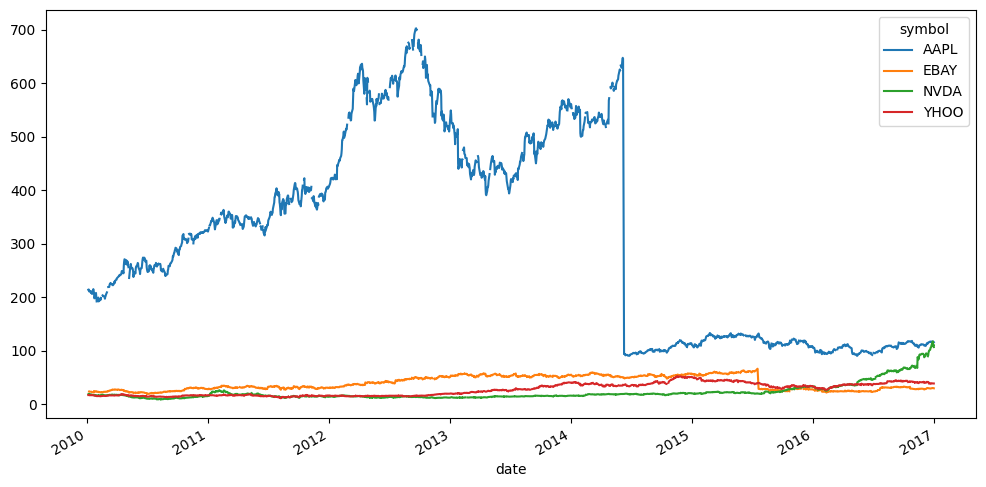

In [65]:
selected_symbols = ['AAPL', 'EBAY', 'NVDA', 'YHOO']
selected_data = prices[prices['symbol'].isin(selected_symbols)]

# Pivot the data so symbols become columns
pivot_prices = selected_data.pivot(columns='symbol', values='close')
 
pivot_prices.plot(figsize=(12, 6))

In [66]:
prices.isna().sum()

symbol       0
close     4245
volume       0
dtype: int64

##### 2. Feature engineer & Transforming

In [67]:
selected_data.head() # initial state

,symbol,close,volume
date,,,
2010-01-04,AAPL,214.009998,123432400.0
2010-01-04,EBAY,23.900000,22511600.0
2010-01-04,NVDA,18.490000,20005100.0
2010-01-04,YHOO,17.100000,16587400.0
2010-01-05,AAPL,214.379993,150476200.0


In [68]:
# pivot so symbols become columns
all_prices = selected_data.reset_index().pivot(index='date', columns='symbol', values='close')

all_prices.head() # present state

symbol,AAPL,EBAY,NVDA,YHOO
date,,,,
2010-01-04,214.009998,23.900000,18.490000,17.100000
2010-01-05,214.379993,NaN,18.760000,17.230000
2010-01-06,210.969995,23.500000,18.879999,17.170000
2010-01-07,210.580000,23.229998,NaN,16.700001
2010-01-08,211.980005,23.509999,18.549999,16.700001


- To fix missing values, we will use interpolation:

Missing values (close):
symbol
AAPL     87
EBAY    125
NVDA     77
YHOO     84
dtype: int64


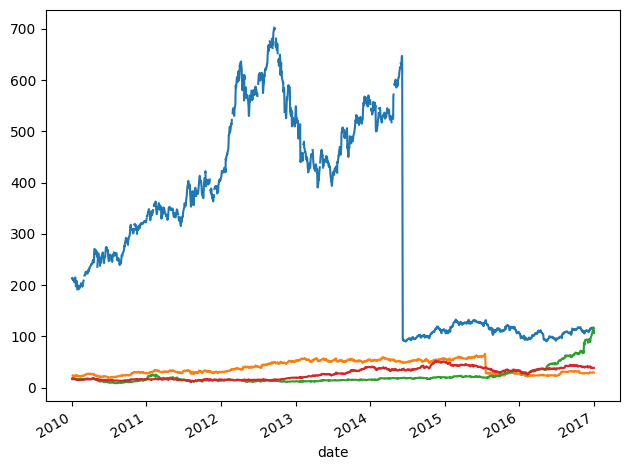

In [71]:
all_prices.plot(legend=False);
plt.tight_layout();

# Count the missing values of each time series
missing_values = all_prices.isnull().sum()
print("Missing values (close):")
print(missing_values)

In [87]:
def interpolate_and_plot(all_prices, interpolation):
    
    # Create a boolean mask for missing values
    missing_values = all_prices.isna()
    
    # Interpolate the missing values
    prices_interp = all_prices.interpolate(interpolation)
    
    # Plot the results, highlighting the interpolated values in black
    fig, ax = plt.subplots(figsize=(10, 5))
    prices_interp.plot(color='k', alpha=0.7, ax=ax, legend=False);
    
    # Note plot the interpolated values on top in blue
    prices_interp[missing_values].plot(ax=ax, color='b', lw=3, legend=False);
    plt.show()
    
    return prices_interp


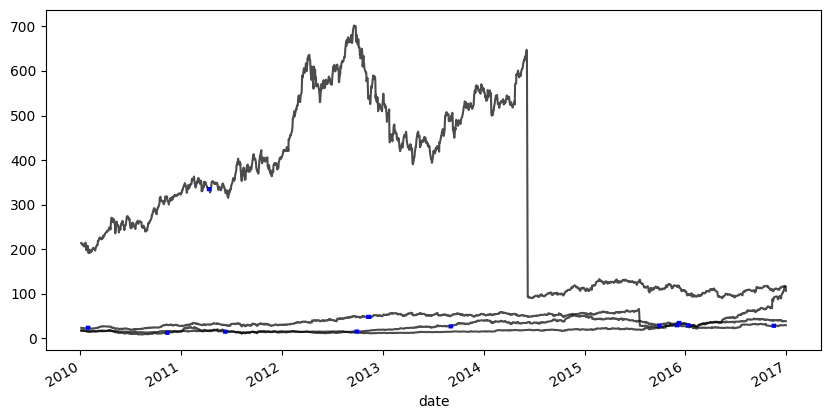

symbol,AAPL,EBAY,NVDA,YHOO
date,,,,
2010-01-04,214.009998,23.900000,18.490000,17.100000
2010-01-05,214.379993,23.900000,18.760000,17.230000
2010-01-06,210.969995,23.500000,18.879999,17.170000
2010-01-07,210.580000,23.229998,18.879999,16.700001
2010-01-08,211.980005,23.509999,18.549999,16.700001
...,...,...,...,...
2016-12-23,116.519997,29.790001,109.779999,38.660000
2016-12-27,117.260002,30.240000,117.320000,38.919998
2016-12-28,116.760002,30.010000,109.250000,38.730000


In [88]:
interpolation_type = 'zero'
interpolate_and_plot(all_prices, interpolation_type)

- interpolation_type of `zero`:

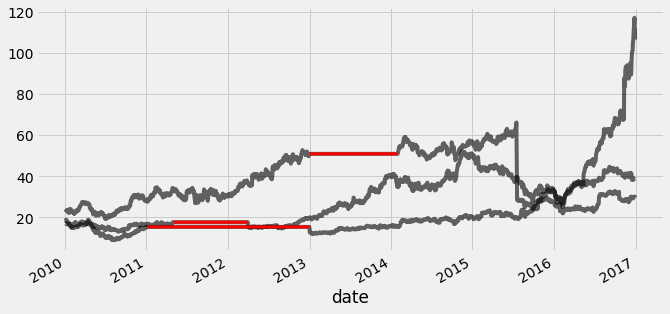

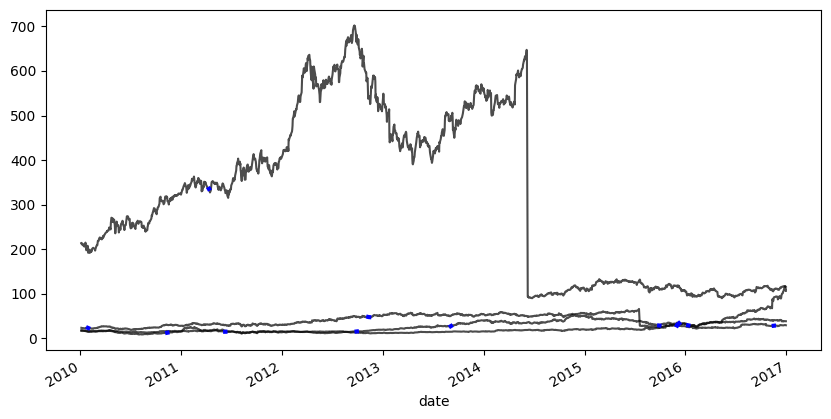

symbol,AAPL,EBAY,NVDA,YHOO
date,,,,
2010-01-04,214.009998,23.900000,18.490000,17.100000
2010-01-05,214.379993,23.700000,18.760000,17.230000
2010-01-06,210.969995,23.500000,18.879999,17.170000
2010-01-07,210.580000,23.229998,18.714999,16.700001
2010-01-08,211.980005,23.509999,18.549999,16.700001
...,...,...,...,...
2016-12-23,116.519997,29.790001,109.779999,38.660000
2016-12-27,117.260002,30.240000,117.320000,38.919998
2016-12-28,116.760002,30.010000,109.250000,38.730000


In [89]:
interpolation_type = 'linear'
interpolate_and_plot(all_prices, interpolation_type)

- interpolation_type of `linear`:

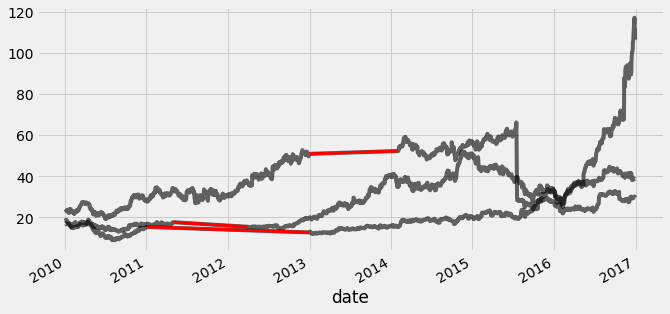

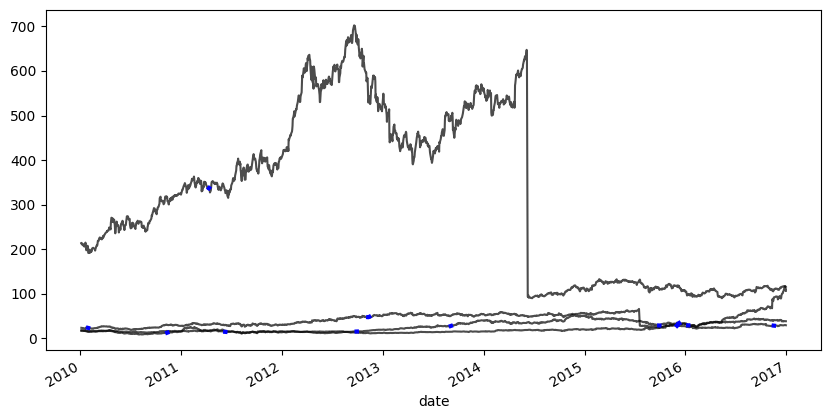

In [90]:
interpolation_type = 'quadratic'
df = interpolate_and_plot(all_prices, interpolation_type)

- interpolation_type of `quadratic`:

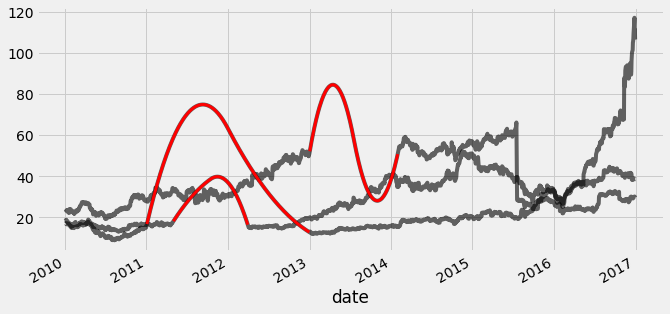

In [92]:
# check missing value after using `quadratic` interpolution:
df.isna().sum().sort_index()

symbol
AAPL    0
EBAY    0
NVDA    0
YHOO    0
dtype: int64

C:\Users\Zen7\AppData\Local\Temp\ipykernel_7288\2834414901.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_value = series[-1]


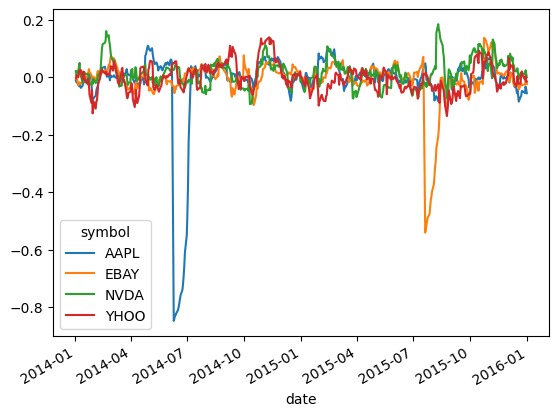

In [ ]:
# Transforming
# Calculates the percentage change between the most recent price and the average price of the previous 20 days.
def percent_change(series):
    # Collect all *but* the last value of this window, then the final value
    previous_values = series[:-1] # first 19 days
    last_value = series[-1]  # last day (day 20)
    
    # Calculate the % difference between the last value and the average of previous 19 days (previous_values)
    percent_change = (last_value - np.mean(previous_values)) / np.mean(previous_values)
    return percent_change

# Apply your custom function and plot
prices_perc = df.rolling(20).apply(percent_change)
prices_perc.loc["2014":"2015"].plot();

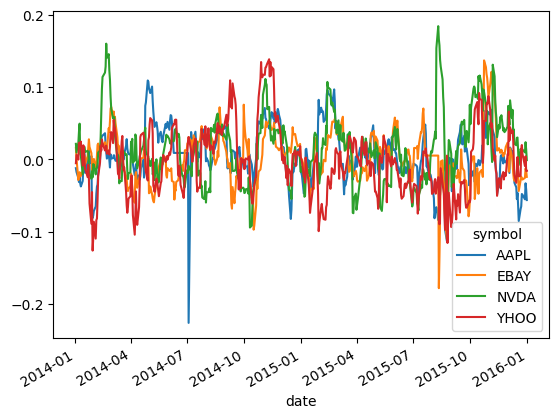

In [100]:
def replace_outliers(series):
    # Calculate the absolute difference of each timepoint from the series mean
    absolute_differences_from_mean = np.abs(series - np.mean(series))
    
    # Calculate a mask for the difference that are > 3 standard deviations from zero
    this_mask = absolute_differences_from_mean > (np.std(series) * 3)
    
    # Replace these values with the median across the data
    series[this_mask] = np.nanmedian(series)
    return series

# Apply your preprocessing functino to the timeseries and plot the results
prices_perc = prices_perc.apply(replace_outliers)
prices_perc.loc["2014":"2015"].plot();

C:\Users\Zen7\AppData\Local\Temp\ipykernel_7288\3209946322.py:7: FutureWarning: The provided callable <function min at 0x000001EB93D276A0> is currently using Rolling.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  features = prices_perc_rolling.aggregate(features_to_calculate)
C:\Users\Zen7\AppData\Local\Temp\ipykernel_7288\3209946322.py:7: FutureWarning: The provided callable <function max at 0x000001EB93D27560> is currently using Rolling.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  features = prices_perc_rolling.aggregate(features_to_calculate)
C:\Users\Zen7\AppData\Local\Temp\ipykernel_7288\3209946322.py:7: FutureWarning: The provided callable <function mean at 0x000001EB93D27F60> is currently using Rolling.mean. In a future version of pandas, the provided callable will be used directly. To keep curre

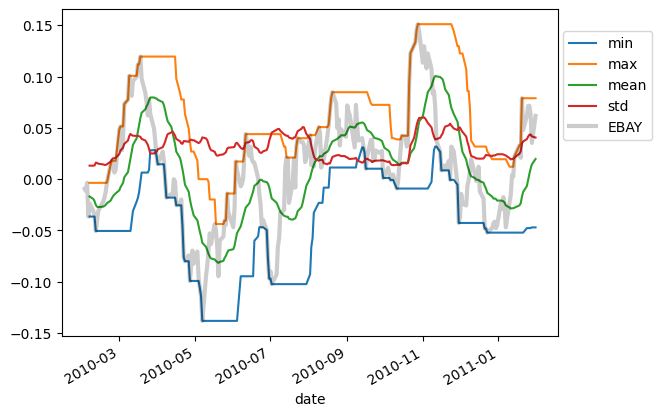

In [101]:
prices_perc_rolling = prices_perc['EBAY'].rolling(20, min_periods=5, closed='right')

# Define the features you'll calculate for each window
features_to_calculate = [np.min, np.max, np.mean, np.std]

# Calculate these features for your rolling window object
features = prices_perc_rolling.aggregate(features_to_calculate)

# Plot the results
ax = features.loc[:"2011-01"].plot();
prices_perc['EBAY'].loc[:"2011-01"].plot(ax=ax, color='k', alpha=0.2, lw=3);
ax.legend(loc=(1.01, 0.6));

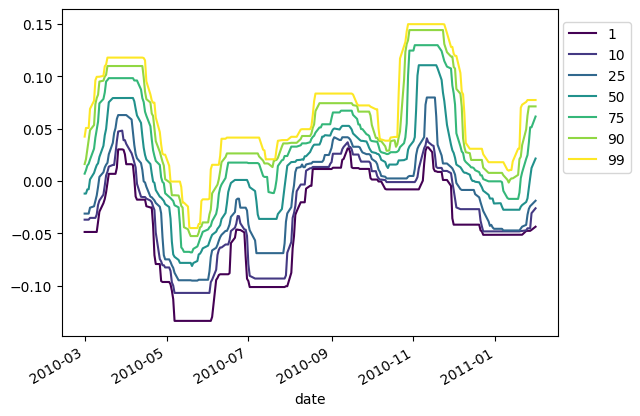

In [ ]:
from functools import partial
percentiles = [1, 10, 25, 50, 75, 90, 99]

# Use a list comprehension to create a partial function for each quantile
percentile_functions = [partial(np.percentile, q=percentile) for percentile in percentiles]

# Calculate each of these quantiles on the data using a rolling window
prices_perc_rolling = prices_perc['EBAY'].rolling(20, min_periods=5, closed='right')
features_percentiles = prices_perc_rolling.aggregate(percentile_functions)

# Plot a subset of the result
ax = features_percentiles.loc[:"2011-01"].plot(cmap=plt.cm.viridis);
ax.legend(percentiles, loc=(1.01, 0.5));

In [115]:
prices_perc['day_of_week'] = prices_perc.index.dayofweek
prices_perc['month_of_year'] = prices_perc.index.month
prices_perc['quarter_of_year'] = prices_perc.index.quarter

# Print prices_perc
prices_perc.head()

symbol,AAPL,EBAY,NVDA,YHOO,day_of_week,month_of_year,quarter_of_year
date,,,,,,,
2010-01-04,NaN,NaN,NaN,NaN,0,1,1
2010-01-05,NaN,NaN,NaN,NaN,1,1,1
2010-01-06,NaN,NaN,NaN,NaN,2,1,1
2010-01-07,NaN,NaN,NaN,NaN,3,1,1
2010-01-08,NaN,NaN,NaN,NaN,4,1,1


##### 3. Train and test using Ridge model

In [119]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

prices_perc = prices_perc.dropna() # drop 19 NaN

# Use stock symbols to extract training data
X = prices_perc.drop('AAPL', axis=1)  # All columns EXCEPT AAPL
y = prices_perc['AAPL']  # Target

# Fit and score the model with cross-validation
scores = cross_val_score(Ridge(), X, y, cv=3)
print(scores)

[ 0.00159947 -0.12895229  0.1490027 ]


In [120]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Split our data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,
                                                   shuffle=False, random_state=1)

# Fit our model and generate predictions
model = Ridge()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
score = r2_score(y_test, predictions)
print(score)

0.1876622427168695


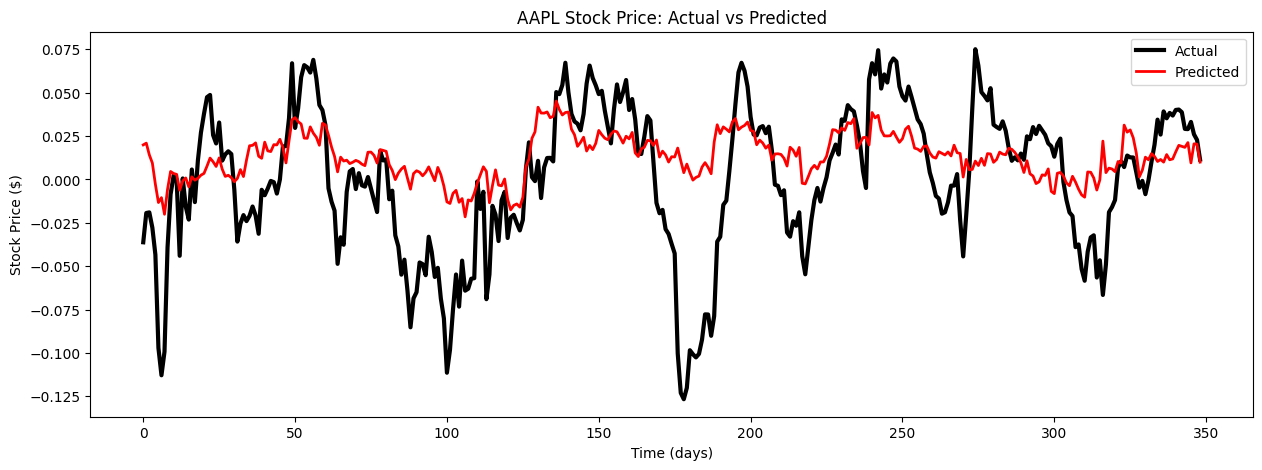

In [121]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(range(len(y_test)), y_test, color='k', lw=3, label='Actual')
ax.plot(range(len(predictions)), predictions, color='r', lw=2, label='Predicted')

ax.set_xlabel('Time (days)')  # x-axis label
ax.set_ylabel('Stock Price ($)')  # y-axis label
ax.set_title('AAPL Stock Price: Actual vs Predicted')
ax.legend()
plt.show()